In [11]:
import folium
# [Latitude, Longitude]
joao_pessoa = [-7.1150, -34.8906]
campina_grande = [-7.22833, -35.8853]

# 1. Criando o mapa base centralizado no meio da Paraíba
mapa_trem = folium.Map(location=[-7.17, -35.37], zoom_start=10)

folium.PolyLine(
    locations=[joao_pessoa, campina_grande],
    color='blue', # Cor da linha
    weight=5,     # Espessura da linha
    tooltip='Rota Expresso JP-CG (Via Reta)'
).add_to(mapa_trem)

folium.Marker(
    joao_pessoa, 
    popup='Estação Central João Pessoa', 
    icon=folium.Icon(color='green', icon='train', prefix='fa')
).add_to(mapa_trem)

folium.Marker(
    campina_grande, 
    popup='Estação Aluízio Campos - CG', 
    icon=folium.Icon(color='green', icon='train', prefix='fa')
).add_to(mapa_trem)

mapa_trem

In [12]:
import rasterio

dataset = rasterio.open('relevo_pb.tif')

print("Sucesso! O Python leu o arquivo.")
print("Largura em pixels:", dataset.width)
print("Altura em pixels:", dataset.height)

Sucesso! O Python leu o arquivo.
Largura em pixels: 5400
Altura em pixels: 3600


In [13]:
from shapely.geometry import Point, LineString

estacao_jp = (-34.8906, -7.1150)
estacao_cg = ( -35.8853, -7.22833)

linha_ferrea = LineString([estacao_jp, estacao_cg])

print(f"Comprimento do trilho (em graus): {linha_ferrea.length}")

pontos_da_linha = []

for p in range (0, 101):
    porcentagem = p / 100
    ponto_atual = linha_ferrea.interpolate(porcentagem, normalized=True)
    pontos_da_linha.append(ponto_atual)

print(f"Temos {len(pontos_da_linha)} estacas fincadas a cada 1% do caminho!")

Comprimento do trilho (em graus): 1.0011352450593294
Temos 101 estacas fincadas a cada 1% do caminho!


In [14]:
from pyproj import Geod

# Python: "Use o formato oficial do globo terrestre (WGS84)"
medidor_globo = Geod(ellps="WGS84")

# 2. Pedimos para ele medir o nosso trilho acompanhando a curva da Terra
distancia_metros = medidor_globo.geometry_length(linha_ferrea)

distancia_km = distancia_metros / 1000

print(f"Distância real do trajeto: {distancia_km:.2f} km")

Distância real do trajeto: 110.58 km


In [15]:
coordenadas_brutas = []

for ponto in pontos_da_linha:
    coordenadas_brutas.append((ponto.x, ponto.y))

altitudes = []

for dado_satelite in dataset.sample(coordenadas_brutas):
    altura_metros = dado_satelite[0]
    altitudes.append(altura_metros)

print(f"Altitude na Estação João Pessoa (Estaca 0): {altitudes[0]:.2f} metros")
print(f"Altitude na Estação Campina Grande (Estaca 100): {altitudes[-1]:.2f} metros")

Altitude na Estação João Pessoa (Estaca 0): 5.89 metros
Altitude na Estação Campina Grande (Estaca 100): 517.81 metros


In [ ]:
import folium

mapa_ferrovia = folium.Map(location=[-7.1675, -35.3719], zoom_start=10)

folium.PolyLine(
    locations=[joao_pessoa, campina_grande],
    color='blue',
    weight=3
).add_to(mapa_ferrovia)

# O 'for' para o Folium desenhar as suas 101 estacas
# Usamos a função zip() para passear pela lista de pontos e de altitudes ao mesmo tempo!
for ponto, altura in zip(pontos_da_linha, altitudes):
    folium.CircleMarker(
        location=[ponto.y, ponto.x], # Folium exige o Y primeiro
        radius=2,
        color='red',
        popup=f"Altitude: {altura} m" # O balãozinho quando você clica na bolinha!
    ).add_to(mapa_ferrovia)

mapa_ferrovia

In [17]:
mapa_ferrovia.save('mapa_completo.html')

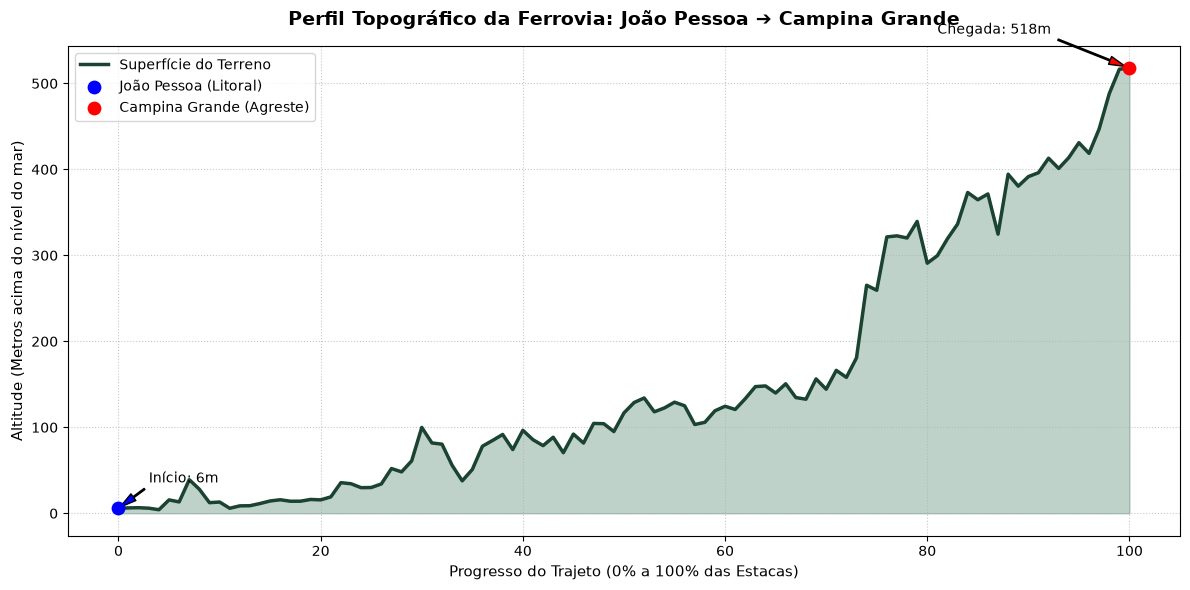

In [ ]:
import matplotlib.pyplot as plt

# 1. Criando a tela do gráfico (12 de largura por 6 de altura)
plt.figure(figsize=(12, 6))

# 2. Desenhando a linha do terreno (verde escuro)
plt.plot(altitudes, color='#1b4332', linewidth=2.5, label='Superfície do Terreno')

# 3. Preenchendo embaixo da linha para dar o efeito de montanha sólida
plt.fill_between(range(len(altitudes)), altitudes, color='#2d6a4f', alpha=0.3)

# 4. Marcando os pontos de partida e chegada no gráfico
plt.scatter([0], [altitudes[0]], color='blue', s=80, zorder=5, label='João Pessoa (Litoral)')
plt.scatter([len(altitudes)-1], [altitudes[-1]], color='red', s=80, zorder=5, label='Campina Grande (Agreste)')

# 5. Adicionando anotações com texto no gráfico
plt.annotate(f'Início: {altitudes[0]:.0f}m', xy=(0, altitudes[0]), xytext=(3, altitudes[0]+30),
             arrowprops=dict(facecolor='blue', shrink=0.05, width=1, headwidth=6))

plt.annotate(f'Chegada: {altitudes[-1]:.0f}m', xy=(len(altitudes)-1, altitudes[-1]), xytext=(len(altitudes)-20, altitudes[-1]+40),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6))

# 6. Estilizando o gráfico (Títulos, Eixos e Grade)
plt.title('Perfil Topográfico da Ferrovia: João Pessoa ➔ Campina Grande', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Progresso do Trajeto (0% a 100% das Estacas)', fontsize=11)
plt.ylabel('Altitude (Metros acima do nível do mar)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left')

# Ajusta as margens para não cortar o texto
plt.tight_layout()

plt.show()